In [1]:
import pandas as pd
import os

In [2]:
df = pd.read_csv('electricity_kosovo.csv')
df

,Datetime (UTC),Country,Zone name,Zone id,Carbon intensity gCO₂eq/kWh (direct),Carbon intensity gCO₂eq/kWh (Life cycle),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),Data source,Data estimated,Data estimation method
0,2025-01-01T00:00:00.000000,Kosovo,Kosovo,XK,612.16,667.76,17.69,13.36,entsoe.eu,False,NaN
1,2025-01-01T01:00:00.000000,Kosovo,Kosovo,XK,641.81,699.26,13.88,9.22,entsoe.eu,False,NaN
2,2025-01-01T02:00:00.000000,Kosovo,Kosovo,XK,643.12,701.16,13.56,8.28,entsoe.eu,False,NaN
3,2025-01-01T03:00:00.000000,Kosovo,Kosovo,XK,641.53,699.58,13.67,8.54,entsoe.eu,False,NaN
4,2025-01-01T04:00:00.000000,Kosovo,Kosovo,XK,647.20,705.28,13.03,8.30,entsoe.eu,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8755,2025-12-31T19:00:00.000000,Kosovo,Kosovo,XK,561.09,609.44,25.64,24.71,entsoe.eu,False,NaN
8756,2025-12-31T20:00:00.000000,Kosovo,Kosovo,XK,604.28,656.04,19.80,18.43,entsoe.eu,False,NaN
8757,2025-12-31T21:00:00.000000,Kosovo,Kosovo,XK,597.68,648.91,20.79,19.65,entsoe.eu,False,NaN
8758,2025-12-31T22:00:00.000000,Kosovo,Kosovo,XK,600.28,652.40,20.10,18.69,entsoe.eu,False,NaN


In [3]:
df.dtypes

Datetime (UTC)                                  str
Country                                         str
Zone name                                       str
Zone id                                         str
Carbon intensity gCO₂eq/kWh (direct)        float64
Carbon intensity gCO₂eq/kWh (Life cycle)    float64
Carbon-free energy percentage (CFE%)        float64
Renewable energy percentage (RE%)           float64
Data source                                     str
Data estimated                                 bool
Data estimation method                          str
dtype: object

In [4]:
df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])

In [5]:
len(df.columns)

11

In [6]:
df[df.isnull().any(axis=1)].reset_index()

,index,Datetime (UTC),Country,Zone name,Zone id,Carbon intensity gCO₂eq/kWh (direct),Carbon intensity gCO₂eq/kWh (Life cycle),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),Data source,Data estimated,Data estimation method
0,0,2025-01-01 00:00:00,Kosovo,Kosovo,XK,612.16,667.76,17.69,13.36,entsoe.eu,False,NaN
1,1,2025-01-01 01:00:00,Kosovo,Kosovo,XK,641.81,699.26,13.88,9.22,entsoe.eu,False,NaN
2,2,2025-01-01 02:00:00,Kosovo,Kosovo,XK,643.12,701.16,13.56,8.28,entsoe.eu,False,NaN
3,3,2025-01-01 03:00:00,Kosovo,Kosovo,XK,641.53,699.58,13.67,8.54,entsoe.eu,False,NaN
4,4,2025-01-01 04:00:00,Kosovo,Kosovo,XK,647.20,705.28,13.03,8.30,entsoe.eu,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8753,8755,2025-12-31 19:00:00,Kosovo,Kosovo,XK,561.09,609.44,25.64,24.71,entsoe.eu,False,NaN
8754,8756,2025-12-31 20:00:00,Kosovo,Kosovo,XK,604.28,656.04,19.80,18.43,entsoe.eu,False,NaN
8755,8757,2025-12-31 21:00:00,Kosovo,Kosovo,XK,597.68,648.91,20.79,19.65,entsoe.eu,False,NaN
8756,8758,2025-12-31 22:00:00,Kosovo,Kosovo,XK,600.28,652.40,20.10,18.69,entsoe.eu,False,NaN


In [7]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Data estimation method                      99.977169
Country                                      0.000000
Datetime (UTC)                               0.000000
Zone name                                    0.000000
Zone id                                      0.000000
Carbon intensity gCO₂eq/kWh (Life cycle)     0.000000
Carbon intensity gCO₂eq/kWh (direct)         0.000000
Carbon-free energy percentage (CFE%)         0.000000
Renewable energy percentage (RE%)            0.000000
Data source                                  0.000000
Data estimated                               0.000000
dtype: float64

In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [9]:
important_cols = [
    'Carbon intensity gCO₂eq/kWh (direct)',
    'Carbon intensity gCO₂eq/kWh (Life cycle)',
    'Carbon-free energy percentage (CFE%)',
    'Renewable energy percentage (RE%)'
]

df[important_cols].isnull().sum()

Carbon intensity gCO₂eq/kWh (direct)        0
Carbon intensity gCO₂eq/kWh (Life cycle)    0
Carbon-free energy percentage (CFE%)        0
Renewable energy percentage (RE%)           0
dtype: int64

In [10]:
df.columns

Index(['Datetime (UTC)', 'Country', 'Zone name', 'Zone id',
       'Carbon intensity gCO₂eq/kWh (direct)',
       'Carbon intensity gCO₂eq/kWh (Life cycle)',
       'Carbon-free energy percentage (CFE%)',
       'Renewable energy percentage (RE%)', 'Data source', 'Data estimated',
       'Data estimation method'],
      dtype='str')

In [11]:
daily = df.resample('D', on='Datetime (UTC)').mean(numeric_only=True)

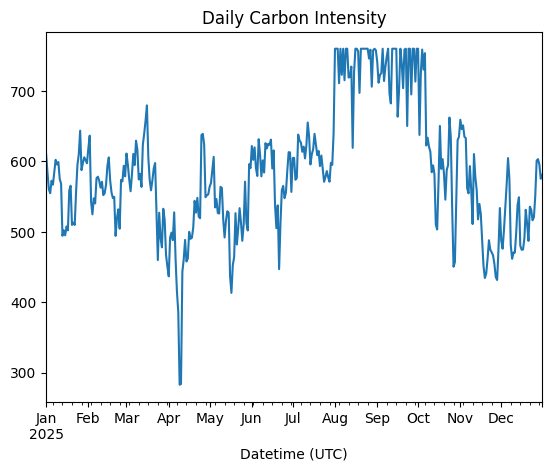

In [12]:
import matplotlib.pyplot as plt

daily['Carbon intensity gCO₂eq/kWh (direct)'].plot()
plt.title("Daily Carbon Intensity")
plt.show()

In [13]:
df = df.drop_duplicates()
df = df.drop(columns=['Data source', 'Data estimated', 'Data estimation method'])

In [14]:
df.columns

Index(['Datetime (UTC)', 'Country', 'Zone name', 'Zone id',
       'Carbon intensity gCO₂eq/kWh (direct)',
       'Carbon intensity gCO₂eq/kWh (Life cycle)',
       'Carbon-free energy percentage (CFE%)',
       'Renewable energy percentage (RE%)'],
      dtype='str')

In [15]:
df['hour'] = df['Datetime (UTC)'].dt.hour
df['day'] = df['Datetime (UTC)'].dt.day
df['month'] = df['Datetime (UTC)'].dt.month
df['weekday'] = df['Datetime (UTC)'].dt.weekday

In [16]:
col = 'Carbon intensity gCO₂eq/kWh (direct)'

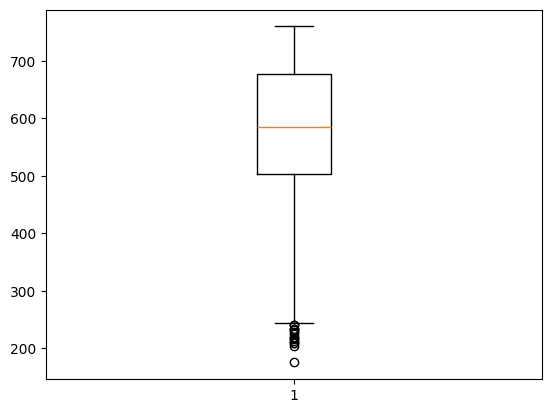

In [17]:
import matplotlib.pyplot as plt

plt.boxplot(df[col])
plt.show()

In [18]:
df_original = df.copy()

df_original.to_csv("df_inc_outliers.csv", index=False)

In [19]:
Q1 = df[col].quantile(0.30)
Q3 = df[col].quantile(0.70)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 319.51599999999996
Upper bound: 856.092


In [20]:
df['is_outlier'] = ((df[col] < lower_bound) | (df[col] > upper_bound))

In [21]:
outlier_percentage = df['is_outlier'].mean() * 100
print(f"Outliers: {outlier_percentage:.2f}%")

Outliers: 0.81%


In [22]:
df_no_outliers = df[df['is_outlier'] == False].copy()

In [23]:

df_no_outliers.to_csv("df_no_outliers.csv", index=False)

In [24]:
outliers = df[df['is_outlier'] == True]

outliers.to_csv("outliers.csv", index=False)

In [25]:
daily_no_outliers = df_no_outliers.resample('D', on='Datetime (UTC)').mean(numeric_only=True)

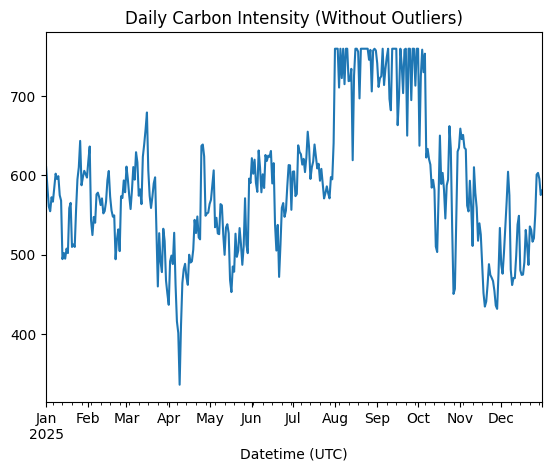

In [26]:
import matplotlib.pyplot as plt

daily_no_outliers['Carbon intensity gCO₂eq/kWh (direct)'].plot()
plt.title("Daily Carbon Intensity (Without Outliers)")
plt.show()

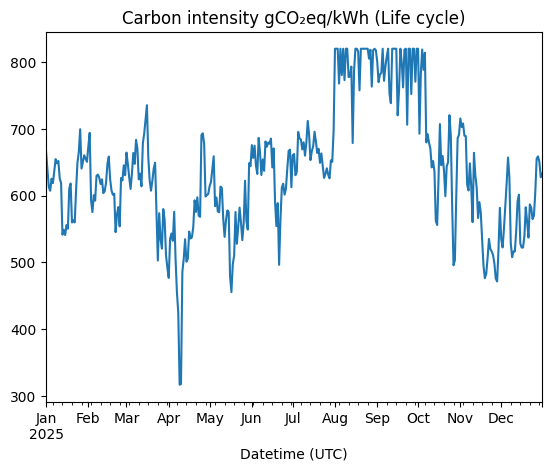

In [27]:
import matplotlib.pyplot as plt

daily['Carbon intensity gCO₂eq/kWh (Life cycle)'].plot()
plt.title("Carbon intensity gCO₂eq/kWh (Life cycle)")
plt.show()

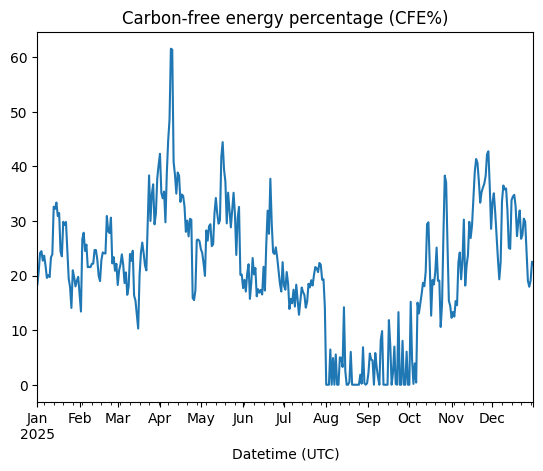

In [28]:
import matplotlib.pyplot as plt

daily['Carbon-free energy percentage (CFE%)'].plot()
plt.title("Carbon-free energy percentage (CFE%)")
plt.show()

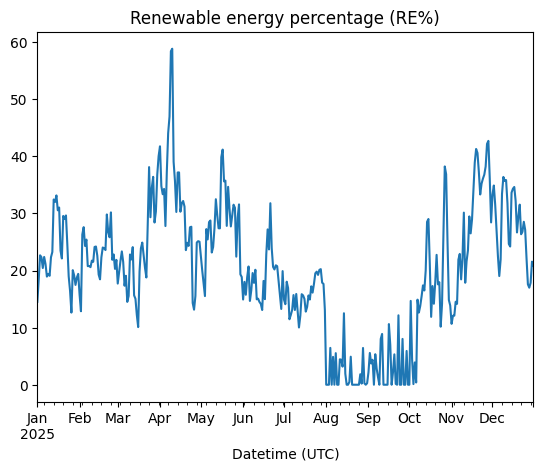

In [29]:
import matplotlib.pyplot as plt

daily['Renewable energy percentage (RE%)'].plot()
plt.title("Renewable energy percentage (RE%)")
plt.show()

In [30]:
cols = [
    "Carbon intensity gCO₂eq/kWh (direct)",
    "Carbon intensity gCO₂eq/kWh (Life cycle)",
    "Carbon-free energy percentage (CFE%)",
    "Renewable energy percentage (RE%)"
]

for col in cols:
    df_no_outliers[col] = pd.to_numeric(df_no_outliers[col], errors="coerce")

In [31]:
import numpy as np

mask = (
    (df_no_outliers["Carbon intensity gCO₂eq/kWh (direct)"] == 760) &
    (df_no_outliers["Carbon-free energy percentage (CFE%)"] == 0)
)

cols = [
    "Carbon intensity gCO₂eq/kWh (direct)",
    "Carbon intensity gCO₂eq/kWh (Life cycle)",
    "Carbon-free energy percentage (CFE%)",
    "Renewable energy percentage (RE%)"
]

df_no_outliers.loc[mask, cols] = np.nan

In [32]:
print(df_no_outliers.isna().sum())

Datetime (UTC)                                 0
Country                                        0
Zone name                                      0
Zone id                                        0
Carbon intensity gCO₂eq/kWh (direct)        1226
Carbon intensity gCO₂eq/kWh (Life cycle)    1226
Carbon-free energy percentage (CFE%)        1226
Renewable energy percentage (RE%)           1226
hour                                           0
day                                            0
month                                          0
weekday                                        0
is_outlier                                     0
dtype: int64


In [33]:
df_no_outliers["Datetime (UTC)"] = pd.to_datetime(df_no_outliers["Datetime (UTC)"])
df_no_outliers = df_no_outliers.sort_values("Datetime (UTC)")
df_no_outliers = df_no_outliers.set_index("Datetime (UTC)")

In [34]:
df_no_outliers[cols] = df_no_outliers[cols].interpolate(method="time")

In [35]:
df_no_outliers = df_no_outliers.reset_index()

In [36]:
print(df_no_outliers.isna().sum())

Datetime (UTC)                              0
Country                                     0
Zone name                                   0
Zone id                                     0
Carbon intensity gCO₂eq/kWh (direct)        0
Carbon intensity gCO₂eq/kWh (Life cycle)    0
Carbon-free energy percentage (CFE%)        0
Renewable energy percentage (RE%)           0
hour                                        0
day                                         0
month                                       0
weekday                                     0
is_outlier                                  0
dtype: int64


In [37]:
daily_2 = df_no_outliers.resample('D', on='Datetime (UTC)').mean(numeric_only=True)

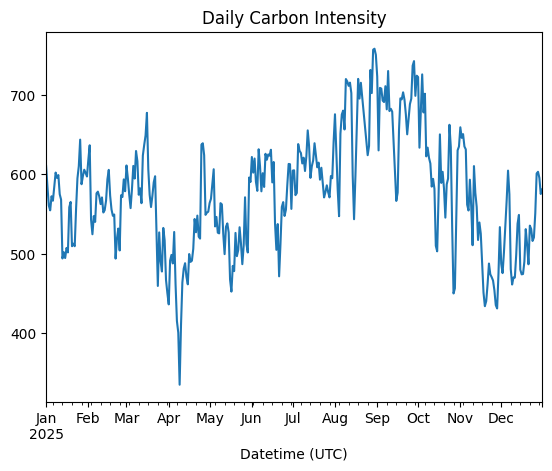

In [38]:
import matplotlib.pyplot as plt

daily_2['Carbon intensity gCO₂eq/kWh (direct)'].plot()
plt.title("Daily Carbon Intensity")
plt.show()

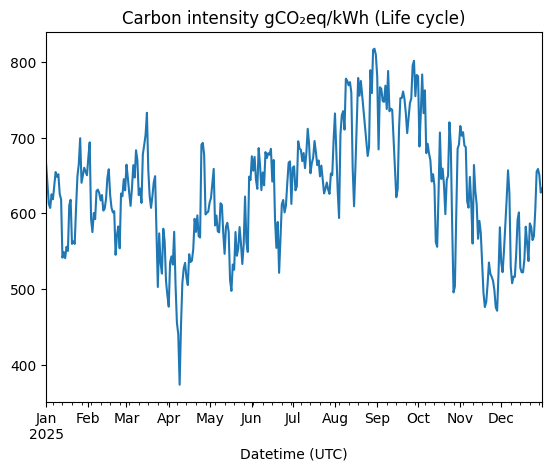

In [39]:
import matplotlib.pyplot as plt

daily_2['Carbon intensity gCO₂eq/kWh (Life cycle)'].plot()
plt.title("Carbon intensity gCO₂eq/kWh (Life cycle)")
plt.show()

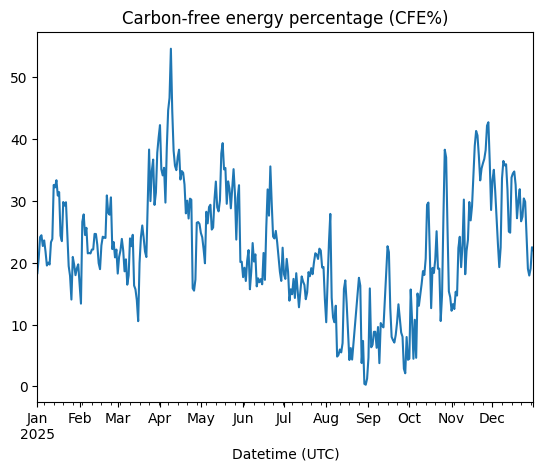

In [40]:
import matplotlib.pyplot as plt

daily_2['Carbon-free energy percentage (CFE%)'].plot()
plt.title("Carbon-free energy percentage (CFE%)")
plt.show()

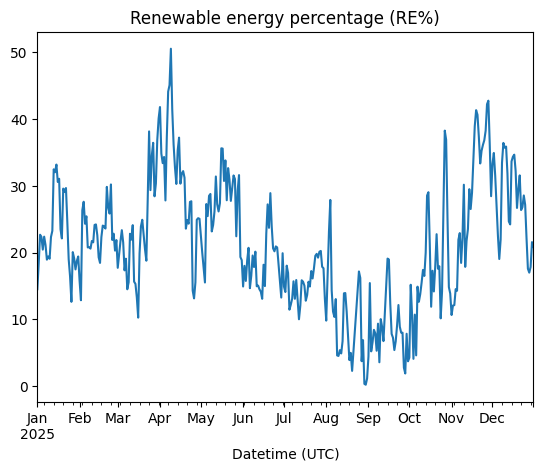

In [41]:
import matplotlib.pyplot as plt

daily_2['Renewable energy percentage (RE%)'].plot()
plt.title("Renewable energy percentage (RE%)")
plt.show()

In [42]:

# SUPERVISED LEARNING MODELS FOR ENERGY CONSUMPTION PREDICTION

import subprocess
import sys

packages = ['scikit-learn', 'xgboost']
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

In [43]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [44]:

df_model = pd.read_csv('df_no_outliers.csv')
df_model['Datetime (UTC)'] = pd.to_datetime(df_model['Datetime (UTC)'])

target_col = 'Carbon intensity gCO₂eq/kWh (direct)'
median_intensity = df_model[target_col].median()

df_model['target'] = (df_model[target_col] > median_intensity).astype(int)

print(f"Median Carbon Intensity: {median_intensity:.2f}")
print(f"Target distribution:\n{df_model['target'].value_counts()}")
print(f"Class balance: High={df_model['target'].sum() / len(df_model) * 100:.1f}%, Low={(1-df_model['target']).sum() / len(df_model) * 100:.1f}%")

Median Carbon Intensity: 585.94
Target distribution:
target
0    4345
1    4344
Name: count, dtype: int64
Class balance: High=50.0%, Low=50.0%


In [45]:

feature_cols = [
    'Carbon intensity gCO₂eq/kWh (Life cycle)',
    'Carbon-free energy percentage (CFE%)',
    'Renewable energy percentage (RE%)',
    'hour',
    'day',
    'month',
    'weekday'
]

df_model_clean = df_model[feature_cols + ['target']].dropna()

X = df_model_clean[feature_cols]
y = df_model_clean['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used:\n{feature_cols}")
print(f"\nFeature statistics:\n{X.describe()}")

Feature matrix shape: (8689, 7)
Target vector shape: (8689,)

Features used:
['Carbon intensity gCO₂eq/kWh (Life cycle)', 'Carbon-free energy percentage (CFE%)', 'Renewable energy percentage (RE%)', 'hour', 'day', 'month', 'weekday']

Feature statistics:
       Carbon intensity gCO₂eq/kWh (Life cycle)  \
count                               8689.000000   
mean                                 642.383325   
std                                  116.823300   
min                                  354.010000   
25%                                  554.100000   
50%                                  639.530000   
75%                                  735.380000   
max                                  820.000000   

       Carbon-free energy percentage (CFE%)  \
count                           8689.000000   
mean                              20.860106   
std                               14.029586   
min                                0.000000   
25%                                9.550000   
50%

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(f"  High (1): {y_train.sum()} samples ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"  Low (0): {(1-y_train).sum()} samples ({(1-y_train).sum()/len(y_train)*100:.1f}%)")

Training set size: 6951 samples (80.0%)
Testing set size: 1738 samples (20.0%)

Training set class distribution:
  High (1): 3475 samples (50.0%)
  Low (0): 3476 samples (50.0%)


In [47]:

# MODEL 1: RANDOM FOREST CLASSIFIER

print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("="*80 + "\n")

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, min_samples_split=5)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)

print("RANDOM FOREST - Performance Metrics:")
print(f"  Accuracy:  {rf_accuracy:.4f}")
print(f"  F1-Score:  {rf_f1:.4f}")
print(f"  Recall:    {rf_recall:.4f}")
print(f"  Precision: {rf_precision:.4f}\n")


MODEL 1: RANDOM FOREST CLASSIFIER

RANDOM FOREST - Performance Metrics:
  Accuracy:  0.9977
  F1-Score:  0.9977
  Recall:    0.9977
  Precision: 0.9977



In [48]:

# MODEL 2: GRADIENT BOOSTING CLASSIFIER

print("\n" + "="*80)
print("MODEL 2: GRADIENT BOOSTING CLASSIFIER")
print("="*80 + "\n")

# Train Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)

# Calculate metrics
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)

print("GRADIENT BOOSTING - Performance Metrics:")
print(f"  Accuracy:  {gb_accuracy:.4f}")
print(f"  F1-Score:  {gb_f1:.4f}")
print(f"  Recall:    {gb_recall:.4f}")
print(f"  Precision: {gb_precision:.4f}\n")



MODEL 2: GRADIENT BOOSTING CLASSIFIER

GRADIENT BOOSTING - Performance Metrics:
  Accuracy:  0.9971
  F1-Score:  0.9971
  Recall:    0.9988
  Precision: 0.9954



In [49]:
# HYPERPARAMETER SWEEP: RF and GB parameter tuning
print("\n" + "="*80)
print("HYPERPARAMETER SWEEP: RF and GB parameters")
print("="*80 + "\n")

param_sweeps = [
    (
        'Random Forest',
        RandomForestClassifier,
        [
            {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 5, 'max_features': 'sqrt', 'bootstrap': True},
            {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 5, 'max_features': 'sqrt', 'bootstrap': True},
            {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'max_features': 'sqrt', 'bootstrap': True},
            {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 10, 'max_features': 'sqrt', 'bootstrap': True},
        ]
    ),
    (
        'Gradient Boosting',
        GradientBoostingClassifier,
        [
            {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 1.0},
            {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 1.0},
            {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8},
            {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8},
        ]
    )
]

results = []

for model_name, model_cls, param_list in param_sweeps:
    for params in param_list:
        model = model_cls(random_state=42, **params)
        if model_name == 'Random Forest' and hasattr(model, 'n_jobs'):
            model.n_jobs = -1
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        results.append({
            'Model': model_name,
            'Params': ', '.join([f'{k}={v}' for k, v in params.items()]),
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred)
        })

results_df = pd.DataFrame(results)
print(results_df[['Model', 'Params', 'Accuracy', 'F1', 'Recall', 'Precision']].to_string(index=False))

best_by_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
print("\nBest configuration by Accuracy:")
print(best_by_accuracy.to_string())


HYPERPARAMETER SWEEP: RF and GB parameters

            Model                                                                                  Params  Accuracy       F1   Recall  Precision
    Random Forest  n_estimators=100, max_depth=15, min_samples_split=5, max_features=sqrt, bootstrap=True  0.997699 0.997699 0.997699   0.997699
    Random Forest  n_estimators=200, max_depth=15, min_samples_split=5, max_features=sqrt, bootstrap=True  0.997123 0.997128 0.998849   0.995413
    Random Forest  n_estimators=100, max_depth=10, min_samples_split=5, max_features=sqrt, bootstrap=True  0.997699 0.997701 0.998849   0.996556
    Random Forest n_estimators=100, max_depth=15, min_samples_split=10, max_features=sqrt, bootstrap=True  0.997123 0.997128 0.998849   0.995413
Gradient Boosting                         n_estimators=100, learning_rate=0.1, max_depth=5, subsample=1.0  0.997123 0.997128 0.998849   0.995413
Gradient Boosting                         n_estimators=200, learning_rate=0.1, max_de

In [50]:

# MODELS COMPARISON

print("\n" + "="*80)
print("MODELS COMPARISON SUMMARY")
print("="*80 + "\n")

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Accuracy': [rf_accuracy, gb_accuracy],
    'F1-Score': [rf_f1, gb_f1],
    'Recall': [rf_recall, gb_recall],
    'Precision': [rf_precision, gb_precision]
})

print(comparison_df.to_string(index=False))
print("\nBest Model by Each Metric:")
print(f"  Best Accuracy:  {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']} ({comparison_df['Accuracy'].max():.4f})")
print(f"  Best F1-Score:  {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"  Best Recall:    {comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']} ({comparison_df['Recall'].max():.4f})")
print(f"  Best Precision: {comparison_df.loc[comparison_df['Precision'].idxmax(), 'Model']} ({comparison_df['Precision'].max():.4f})")


MODELS COMPARISON SUMMARY

            Model  Accuracy  F1-Score   Recall  Precision
    Random Forest  0.997699  0.997699 0.997699   0.997699
Gradient Boosting  0.997123  0.997128 0.998849   0.995413

Best Model by Each Metric:
  Best Accuracy:  Random Forest (0.9977)
  Best F1-Score:  Random Forest (0.9977)
  Best Recall:    Gradient Boosting (0.9988)
  Best Precision: Random Forest (0.9977)


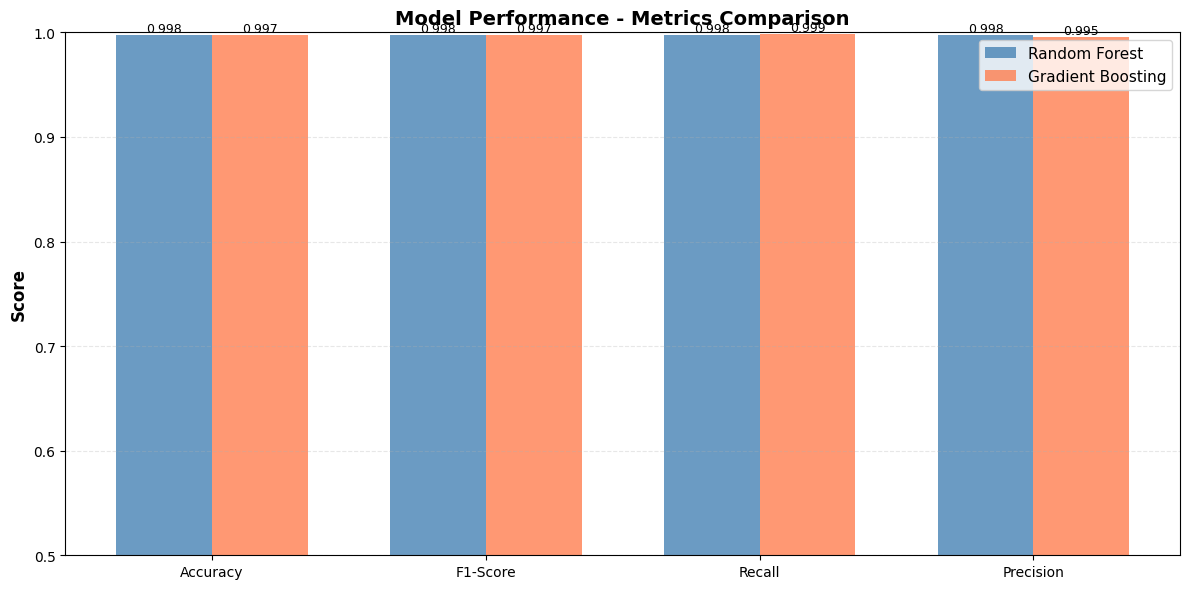

In [51]:
# ============================================================================
# VISUALIZATION 1: METRICS COMPARISON
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'F1-Score', 'Recall', 'Precision']
rf_scores = [rf_accuracy, rf_f1, rf_recall, rf_precision]
gb_scores = [gb_accuracy, gb_f1, gb_recall, gb_precision]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, gb_scores, width, label='Gradient Boosting', color='coral', alpha=0.8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance - Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0.5, 1.0])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

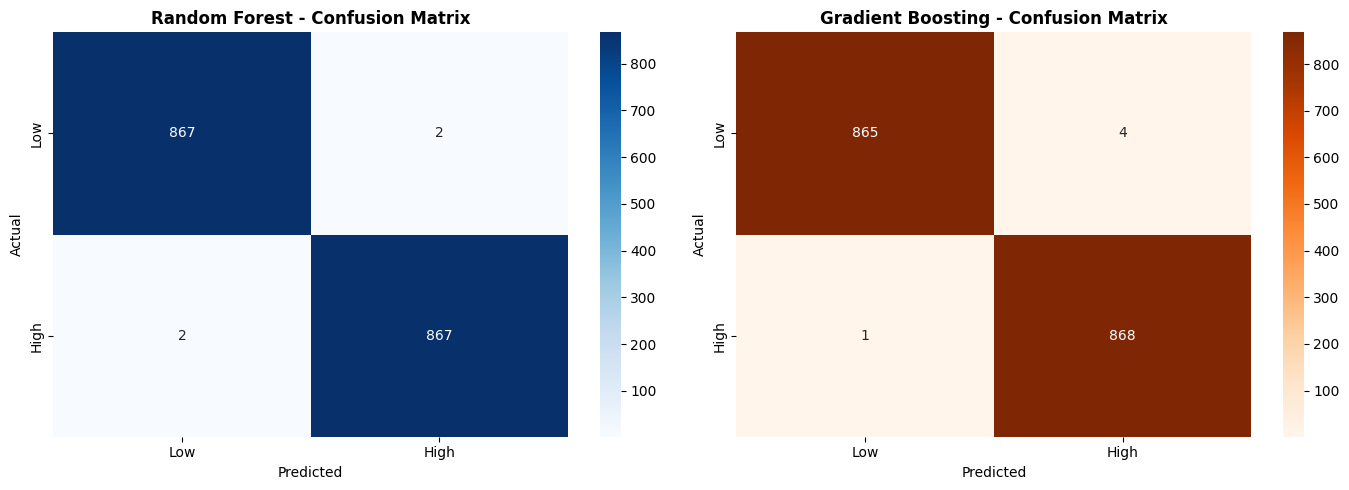

In [52]:
# ============================================================================
# VISUALIZATION 2: CONFUSION MATRICES
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True, 
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion matrix for Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=True,
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
axes[1].set_title('Gradient Boosting - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

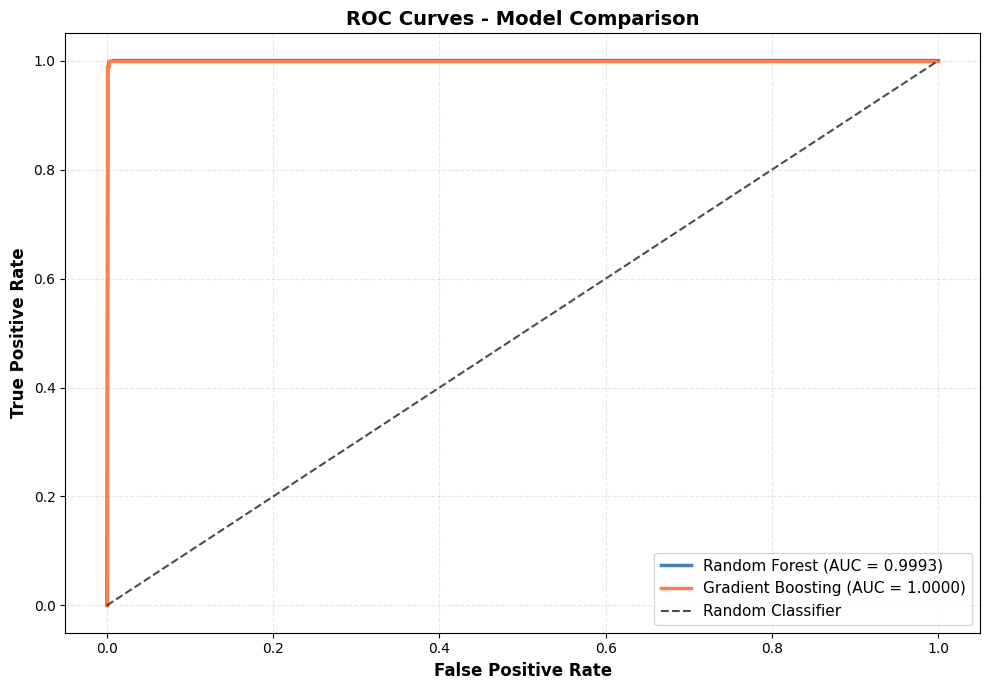

Random Forest AUC: 0.9993
Gradient Boosting AUC: 1.0000


In [53]:
# ============================================================================
# VISUALIZATION 3: ROC CURVES
# ============================================================================

from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC for both models
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb[:, 1])
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', linewidth=2.5, color='steelblue')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.4f})', linewidth=2.5, color='coral')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5, alpha=0.7)

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"Random Forest AUC: {roc_auc_rf:.4f}")
print(f"Gradient Boosting AUC: {roc_auc_gb:.4f}")

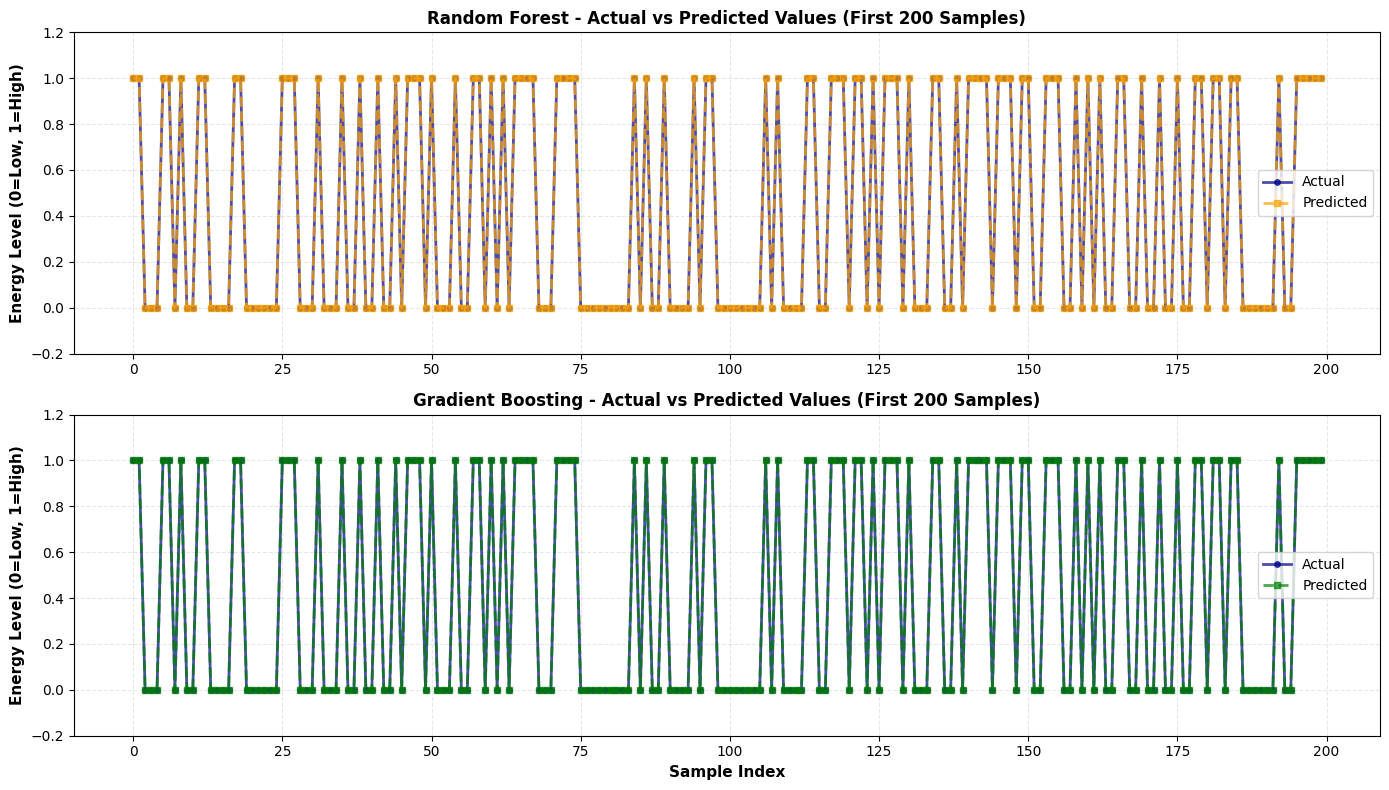

In [54]:
# ============================================================================
# VISUALIZATION 4: ACTUAL VS PREDICTED - TIME SERIES VIEW (Sample)
# ============================================================================

# Create a sample window (first 200 test samples) for better visualization
sample_size = min(200, len(y_test))
sample_indices = np.arange(sample_size)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Random Forest
axes[0].plot(sample_indices, y_test.values[:sample_size], 'o-', label='Actual', 
             linewidth=2, markersize=4, color='darkblue', alpha=0.7)
axes[0].plot(sample_indices, y_pred_rf[:sample_size], 's--', label='Predicted', 
             linewidth=2, markersize=4, color='orange', alpha=0.7)
axes[0].set_ylabel('Energy Level (0=Low, 1=High)', fontsize=11, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted Values (First 200 Samples)', 
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_ylim([-0.2, 1.2])

# Gradient Boosting
axes[1].plot(sample_indices, y_test.values[:sample_size], 'o-', label='Actual', 
             linewidth=2, markersize=4, color='darkblue', alpha=0.7)
axes[1].plot(sample_indices, y_pred_gb[:sample_size], 's--', label='Predicted', 
             linewidth=2, markersize=4, color='green', alpha=0.7)
axes[1].set_xlabel('Sample Index', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Energy Level (0=Low, 1=High)', fontsize=11, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted Values (First 200 Samples)', 
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_ylim([-0.2, 1.2])

plt.tight_layout()
plt.show()

In [55]:
# UNSUPERVISED LEARNING MODELS FOR ENERGY CONSUMPTION PREDICTION

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [56]:

print("STEP 0: DATA PREPARATION FOR CLUSTERING\n")


df_clustering = pd.read_csv('df_no_outliers.csv')
print(f"✓ Loaded df_no_outliers.csv: {df_clustering.shape[0]} samples, {df_clustering.shape[1]} columns")


feature_cols_clustering = [
    'Carbon intensity gCO₂eq/kWh (Life cycle)',
    'Carbon-free energy percentage (CFE%)',
    'Renewable energy percentage (RE%)',
    'hour',
    'day',
    'month',
    'weekday'
]


X_full = df_clustering[feature_cols_clustering].dropna()
print(f"✓ Extracted {len(X_full)} samples with {len(feature_cols_clustering)} features (after dropping NaN)\n")


scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)
print(f"✓ Applied StandardScaler to full dataset")
print(f"  - Each feature: zero mean, unit variance")
print(f"  - Shape: {X_full_scaled.shape}")
print(f"  - Mean: {X_full_scaled.mean(axis=0).round(6)}")  
print(f"  - Std: {X_full_scaled.std(axis=0).round(4)}\n")


print("="*80)
print("STEP 1: OPTIMAL K DETERMINATION (K=2-15)")
print("="*80 + "\n")
print("Testing different K values on FULL scaled dataset...\n")


inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_scores = []
k_values = list(range(2, 16))

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    kmeans_temp.fit(X_full_scaled)
    
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_full_scaled, kmeans_temp.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_full_scaled, kmeans_temp.labels_))
    calinski_scores.append(calinski_harabasz_score(X_full_scaled, kmeans_temp.labels_))


optimal_k_idx = np.argmax(silhouette_scores)
optimal_k = k_values[optimal_k_idx]
best_silhouette_score = silhouette_scores[optimal_k_idx]

print(f"Results Summary (K=2 to K=15):")
print(f"{'K':<4} {'Silhouette':<15} {'Davies-Bouldin':<18} {'Calinski-Harabasz':<18}")
print("-" * 60)
for k, sil, db, cal in zip(k_values, silhouette_scores, davies_bouldin_scores, calinski_scores):
    marker = " ← OPTIMAL" if k == optimal_k else ""
    print(f"{k:<4} {sil:<15.4f} {db:<18.4f} {cal:<18.2f}{marker}")

print(f"\n✓ OPTIMAL K: {optimal_k} (Silhouette: {best_silhouette_score:.4f})")
print(f"✓ This represents the clearest cluster separation\n")




STEP 0: DATA PREPARATION FOR CLUSTERING

✓ Loaded df_no_outliers.csv: 8689 samples, 13 columns
✓ Extracted 8689 samples with 7 features (after dropping NaN)

✓ Applied StandardScaler to full dataset
  - Each feature: zero mean, unit variance
  - Shape: (8689, 7)
  - Mean: [-0.  0. -0.  0.  0.  0. -0.]
  - Std: [1. 1. 1. 1. 1. 1. 1.]

STEP 1: OPTIMAL K DETERMINATION (K=2-15)

Testing different K values on FULL scaled dataset...

Results Summary (K=2 to K=15):
K    Silhouette      Davies-Bouldin     Calinski-Harabasz 
------------------------------------------------------------
2    0.2660          1.4387             3997.50            ← OPTIMAL
3    0.1887          1.7570             2919.45           
4    0.1890          1.6760             2472.62           
5    0.1823          1.6526             2270.36           
6    0.1888          1.6173             2115.06           
7    0.1855          1.5995             1972.48           
8    0.1835          1.5095             1864.47      

In [57]:

X_for_clustering = X_full_scaled


In [58]:
# TRAIN K-MEANS ON FULL DATASET
print("\n" + "="*80)
print("K-MEANS CLUSTERING (Using Full Scaled Dataset)")
print("="*80 + "\n")


kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
kmeans_labels = kmeans.fit_predict(X_full_scaled)


kmeans_inertia = kmeans.inertia_
kmeans_silhouette = silhouette_score(X_full_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_full_scaled, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X_full_scaled, kmeans_labels)

print(f"K-MEANS - Performance Metrics (K={optimal_k}):")
print(f"  ├─ Silhouette Score: {kmeans_silhouette:.4f}")
if kmeans_silhouette > 0.7:
    print(f"  │  → EXCELLENT separation ✓✓")
elif kmeans_silhouette > 0.5:
    print(f"  │  → GOOD separation ✓")
elif kmeans_silhouette > 0.3:
    print(f"  │  → FAIR separation")
else:
    print(f"  │  → POOR separation")
print(f"  ├─ Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"  ├─ Calinski-Harabasz Index: {kmeans_calinski_harabasz:.4f}")
print(f"  └─ Inertia: {kmeans_inertia:.4f}\n")


print(f"Cluster Distribution:")
unique_labels_km, counts_km = np.unique(kmeans_labels, return_counts=True)
for label, count in zip(unique_labels_km, counts_km):
    print(f"  Cluster {label}: {count:5d} samples ({count/len(kmeans_labels)*100:5.1f}%)")
print()





K-MEANS CLUSTERING (Using Full Scaled Dataset)

K-MEANS - Performance Metrics (K=2):
  ├─ Silhouette Score: 0.2660
  │  → POOR separation
  ├─ Davies-Bouldin Index: 1.4387
  ├─ Calinski-Harabasz Index: 3997.5024
  └─ Inertia: 41654.7407

Cluster Distribution:
  Cluster 0:  4535 samples ( 52.2%)
  Cluster 1:  4154 samples ( 47.8%)



In [59]:
# Train Gaussian Mixture Model (GMM)

print("\n" + "="*80)
print("MODEL 2: GAUSSIAN MIXTURE MODEL (GMM)")
print("="*80 + "\n")


gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_full_scaled)
gmm_proba = gmm.predict_proba(X_full_scaled)


gmm_bic = gmm.bic(X_full_scaled)
gmm_aic = gmm.aic(X_full_scaled)
gmm_silhouette = silhouette_score(X_full_scaled, gmm_labels)
gmm_davies_bouldin = davies_bouldin_score(X_full_scaled, gmm_labels)
gmm_calinski_harabasz = calinski_harabasz_score(X_full_scaled, gmm_labels)

print(f"GAUSSIAN MIXTURE MODEL - Performance Metrics:")
print(f"  Number of Clusters: {optimal_k}")
print(f"  BIC (Bayesian Information Criterion): {gmm_bic:.4f}")
print(f"  AIC (Akaike Information Criterion): {gmm_aic:.4f}")
print(f"  Silhouette Score: {gmm_silhouette:.4f}")
print(f"    → Score interpretation: Well-separated clusters ✓" if gmm_silhouette > 0.5 else "    → Score interpretation: Moderate cluster separation")
print(f"  Davies-Bouldin Index: {gmm_davies_bouldin:.4f}")
print(f"  Calinski-Harabasz Index: {gmm_calinski_harabasz:.4f}")


print(f"Cluster Distribution:")
unique_labels_gmm, counts_gmm = np.unique(gmm_labels, return_counts=True)
for label, count in zip(unique_labels_gmm, counts_gmm):
    print(f"  Cluster {label}: {count} samples ({count/len(gmm_labels)*100:.1f}%)")



MODEL 2: GAUSSIAN MIXTURE MODEL (GMM)

GAUSSIAN MIXTURE MODEL - Performance Metrics:
  Number of Clusters: 2
  BIC (Bayesian Information Criterion): 50502.1519
  AIC (Akaike Information Criterion): 50000.1951
  Silhouette Score: 0.1876
    → Score interpretation: Moderate cluster separation
  Davies-Bouldin Index: 1.3629
  Calinski-Harabasz Index: 1659.0279
Cluster Distribution:
  Cluster 0: 7475 samples (86.0%)
  Cluster 1: 1214 samples (14.0%)


In [60]:
# Clustering Models Comparison

print("\n" + "="*80)
print("CLUSTERING MODELS COMPARISON")
print("="*80 + "\n")

clustering_comparison = pd.DataFrame({
    'Model': ['K-Means', 'Gaussian Mixture Model'],
    'Clusters': [optimal_k, optimal_k],
    'Silhouette Score': [kmeans_silhouette, gmm_silhouette],
    'Davies-Bouldin Index': [kmeans_davies_bouldin, gmm_davies_bouldin],
    'Calinski-Harabasz Index': [kmeans_calinski_harabasz, gmm_calinski_harabasz],
    'Inertia/BIC': [kmeans_inertia, gmm_bic]
})

print(clustering_comparison.to_string(index=False))
print("\n✓ Best model for clustering: ", end="")

if kmeans_silhouette > gmm_silhouette:
    print(f"K-Means (Silhouette: {kmeans_silhouette:.4f})")
else:
    print(f"Gaussian Mixture Model (Silhouette: {gmm_silhouette:.4f})")



CLUSTERING MODELS COMPARISON

                 Model  Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index  Inertia/BIC
               K-Means         2          0.266041              1.438673              3997.502387 41654.740659
Gaussian Mixture Model         2          0.187570              1.362917              1659.027922 50502.151866

✓ Best model for clustering: K-Means (Silhouette: 0.2660)


In [61]:
# PCA Dimensionality Reduction for 2D Visualization

print("\n" + "="*80)
print("PREPARING VISUALIZATIONS: PCA DIMENSIONALITY REDUCTION")
print("="*80 + "\n")


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_scaled)

print(f"PCA Explained Variance Ratio:")
print(f"  Component 1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  Component 2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  Total Variance Explained: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)\n")


kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)



PREPARING VISUALIZATIONS: PCA DIMENSIONALITY REDUCTION

PCA Explained Variance Ratio:
  Component 1: 0.4468 (44.68%)
  Component 2: 0.1444 (14.44%)
  Total Variance Explained: 0.5912 (59.12%)



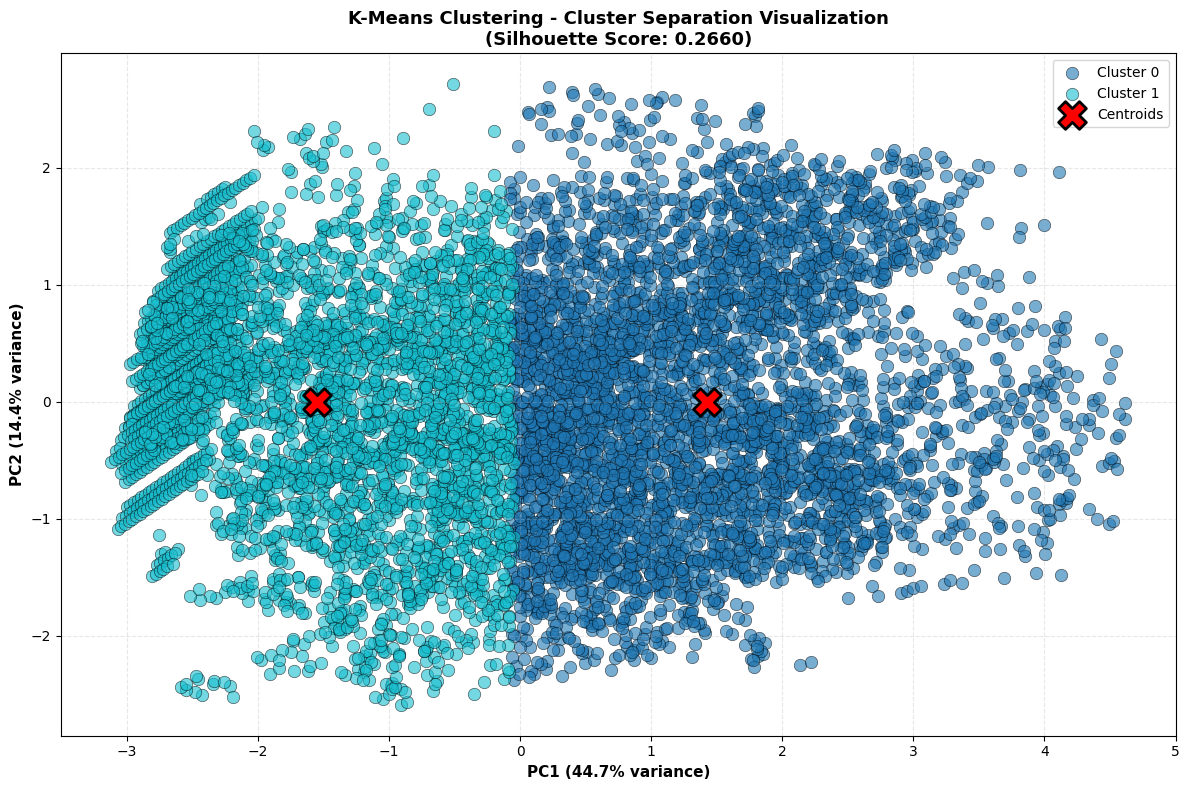

In [62]:

# VISUALIZATION 1: K-MEANS CLUSTERS IN 2D (PCA Space) - CLUSTER SEPARATION

fig, ax = plt.subplots(figsize=(12, 8))

# Plot clusters with different colors
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    cluster_points = X_pca[kmeans_labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=[colors[i]], label=f'Cluster {i}', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], 
           c='red', marker='X', s=400, edgecolors='black', linewidth=2, 
           label='Centroids', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11, fontweight='bold')
ax.set_title(f'K-Means Clustering - Cluster Separation Visualization\n(Silhouette Score: {kmeans_silhouette:.4f})', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


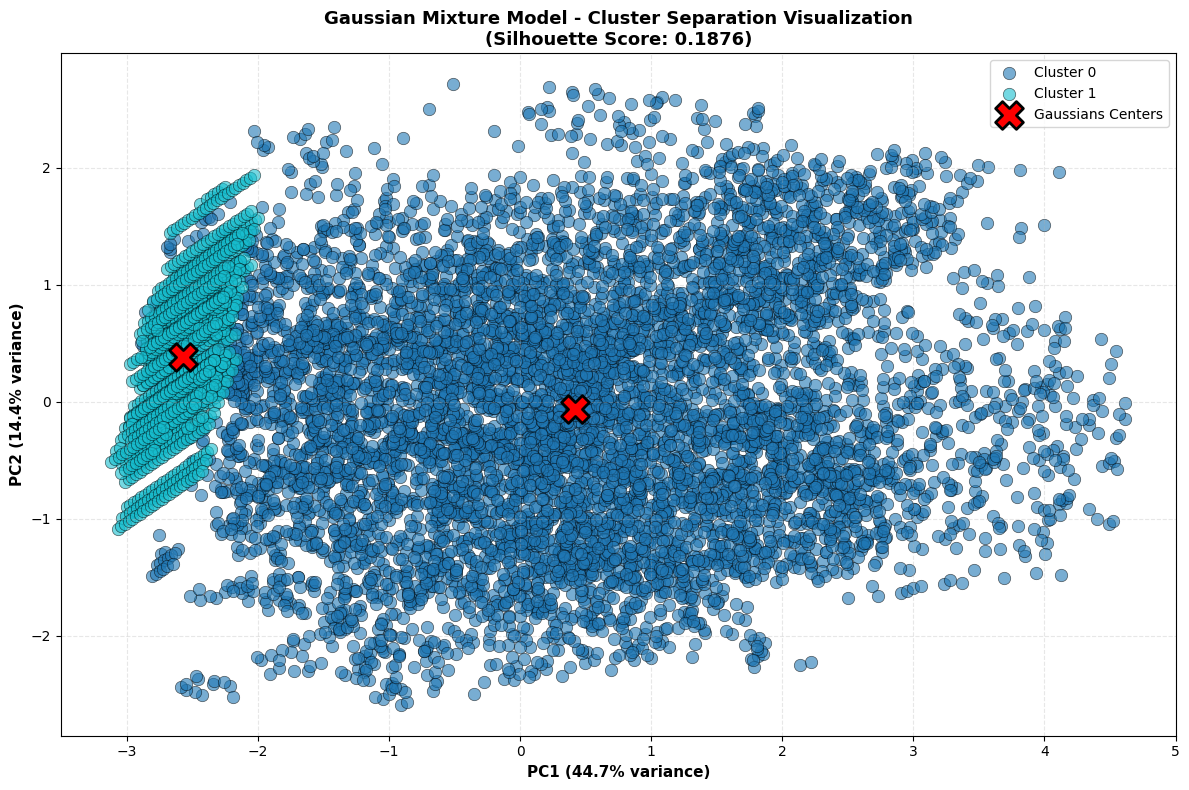

In [63]:

# VISUALIZATION 2: GAUSSIAN MIXTURE MODEL CLUSTERS IN 2D (PCA Space)

fig, ax = plt.subplots(figsize=(12, 8))


colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    cluster_points = X_pca[gmm_labels == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=[colors[i]], label=f'Cluster {i}', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)


gmm_means_pca = pca.transform(gmm.means_)
ax.scatter(gmm_means_pca[:, 0], gmm_means_pca[:, 1], 
           c='red', marker='X', s=400, edgecolors='black', linewidth=2, 
           label='Gaussians Centers', zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11, fontweight='bold')
ax.set_title(f'Gaussian Mixture Model - Cluster Separation Visualization\n(Silhouette Score: {gmm_silhouette:.4f})', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()



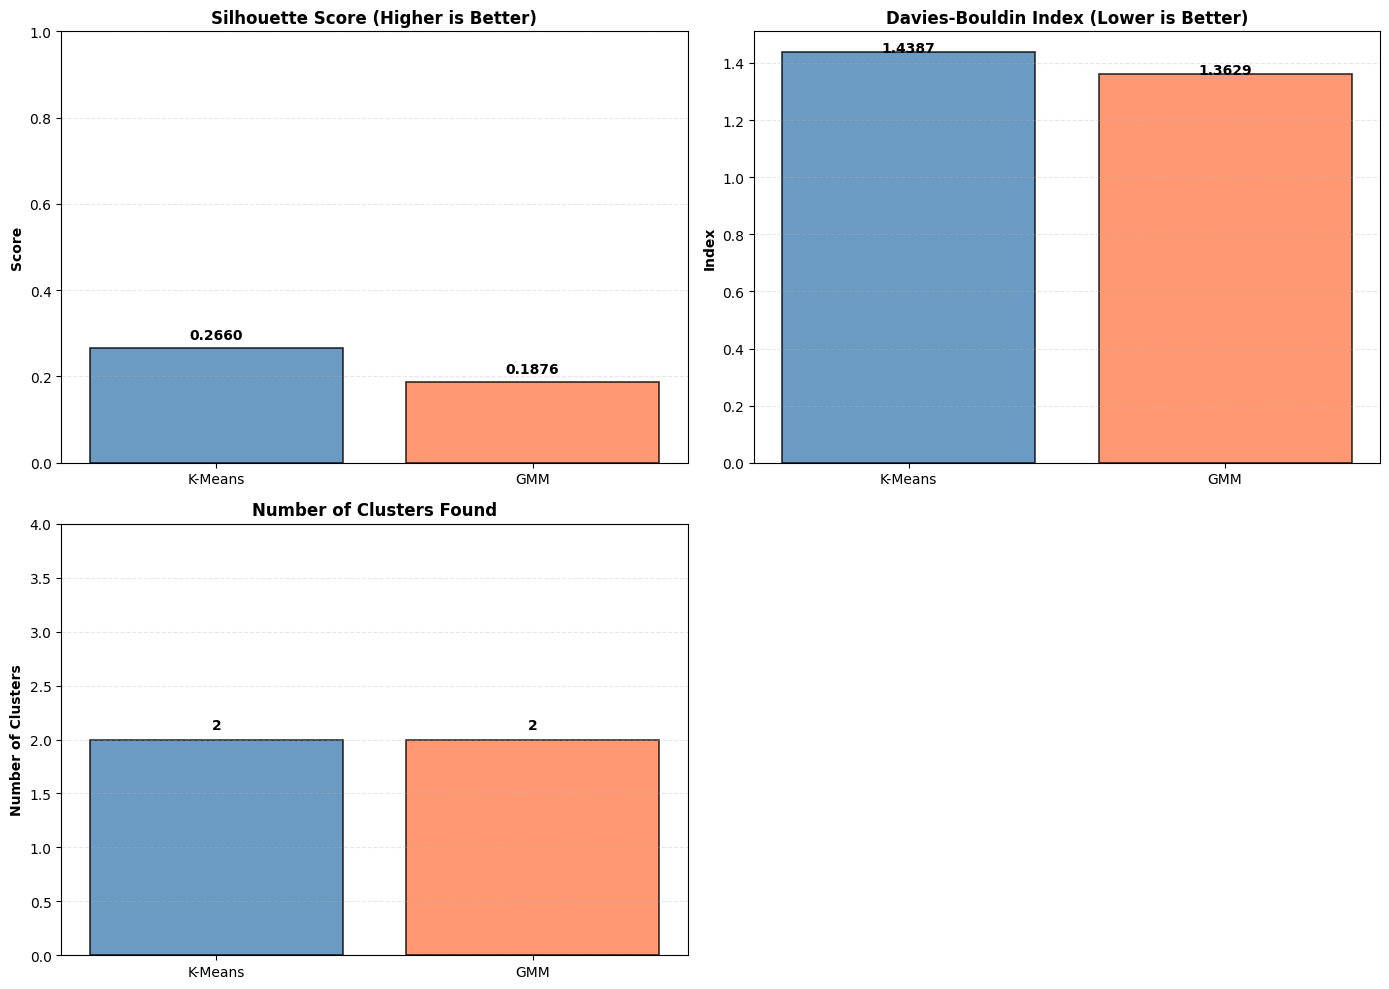

In [64]:
# VISUALIZATION 3: CLUSTERING METRICS COMPARISON

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['K-Means', 'GMM']
colors_bars = ['steelblue', 'coral']


# Silhouette Score

silhouette_scores = [kmeans_silhouette, gmm_silhouette]

axes[0, 0].bar(models, silhouette_scores, color=colors_bars, alpha=0.8,
               edgecolor='black', linewidth=1.2)

axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].set_title('Silhouette Score (Higher is Better)', fontweight='bold')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.3)

for i, v in enumerate(silhouette_scores):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')


# Davies-Bouldin Index

davies_bouldin_scores = [kmeans_davies_bouldin, gmm_davies_bouldin]

axes[0, 1].bar(models, davies_bouldin_scores, color=colors_bars, alpha=0.8,
               edgecolor='black', linewidth=1.2)

axes[0, 1].set_ylabel('Index', fontweight='bold')
axes[0, 1].set_title('Davies-Bouldin Index (Lower is Better)', fontweight='bold')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.3)

for i, v in enumerate(davies_bouldin_scores):
    axes[0, 1].text(i, v, f'{v:.4f}', ha='center', fontweight='bold')



# Cluster Count

cluster_counts = [optimal_k, optimal_k]

axes[1, 0].bar(models, cluster_counts, color=colors_bars, alpha=0.8,
               edgecolor='black', linewidth=1.2)

axes[1, 0].set_ylabel('Number of Clusters', fontweight='bold')
axes[1, 0].set_title('Number of Clusters Found', fontweight='bold')
axes[1, 0].set_ylim(0, optimal_k + 2)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.3)

for i, v in enumerate(cluster_counts):
    axes[1, 0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')



# Remove empty subplot

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


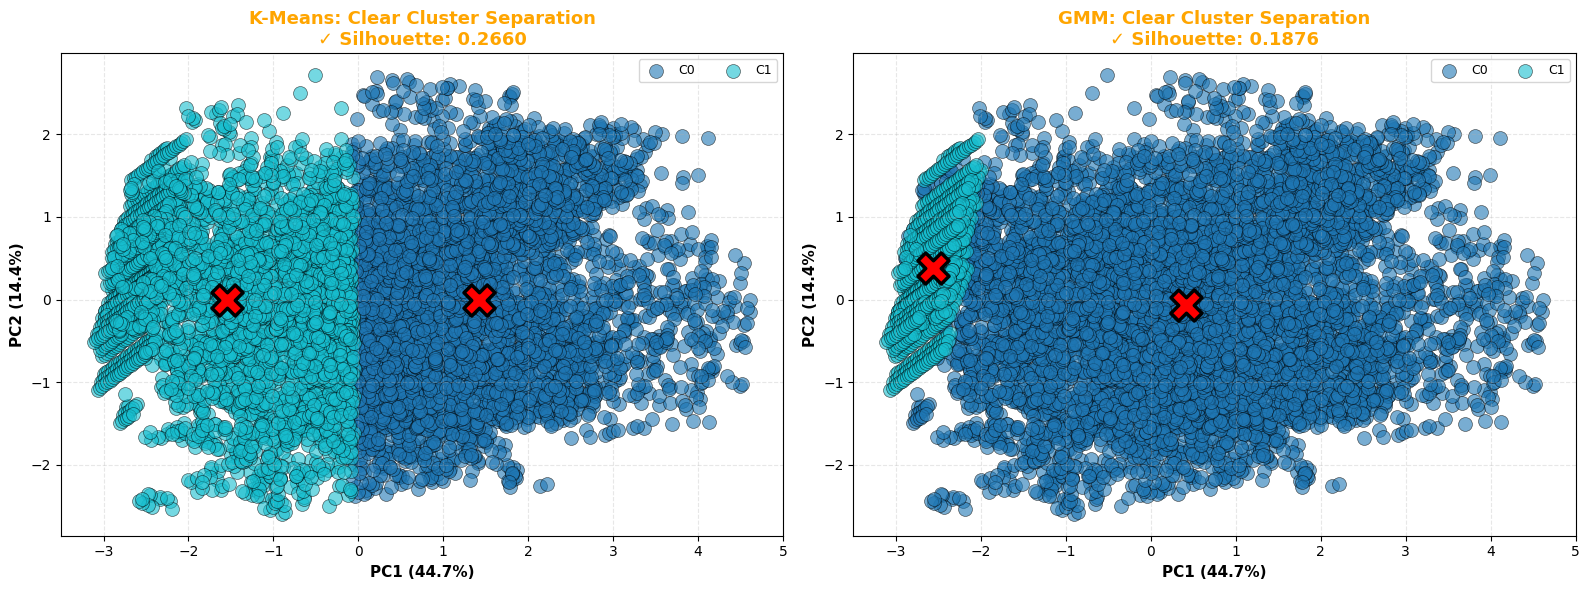

In [65]:

# VISUALIZATION 4: SIDE-BY-SIDE CLUSTER SEPARATION COMPARISON

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Clustering
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    cluster_points = X_pca[kmeans_labels == i]
    axes[0].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                   c=[colors[i]], label=f'C{i}', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

centers_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], 
               c='red', marker='X', s=500, edgecolors='black', linewidth=2.5, zorder=5)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11, fontweight='bold')
axes[0].set_title(f'K-Means: Clear Cluster Separation\n✓ Silhouette: {kmeans_silhouette:.4f}', 
                 fontsize=13, fontweight='bold', color='green' if kmeans_silhouette > 0.5 else 'orange')
axes[0].legend(fontsize=9, ncol=2, loc='best')
axes[0].grid(alpha=0.3, linestyle='--')

# GMM Clustering
for i in range(optimal_k):
    cluster_points = X_pca[gmm_labels == i]
    axes[1].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                   c=[colors[i]], label=f'C{i}', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

gmm_means_pca = pca.transform(gmm.means_)
axes[1].scatter(gmm_means_pca[:, 0], gmm_means_pca[:, 1], 
               c='red', marker='X', s=500, edgecolors='black', linewidth=2.5, zorder=5)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11, fontweight='bold')
axes[1].set_title(f'GMM: Clear Cluster Separation\n✓ Silhouette: {gmm_silhouette:.4f}', 
                 fontsize=13, fontweight='bold', color='green' if gmm_silhouette > 0.5 else 'orange')
axes[1].legend(fontsize=9, ncol=2, loc='best')
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()



# Faza e tretë - Analiza dhe evaluimi (ri-trajnimi) dhe aplikimi i veglave të ML

Në këtë fazë, do të analizojmë dhe vlerësojmë modelet e trajnuara, do të bëjmë ri-trajnim me optimizim të hiperparametrave dhe do të aplikojmë vegla të tjera të Machine Learning për të përmirësuar performancën dhe interpretimin e rezultateve.

In [66]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

In [67]:
import numpy as np

In [68]:
# Hiperparametra tuning për Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train_scaled, y_train)
print("Më i miri parametri për Random Forest:")
print(rf_grid_search.best_params_)
print(f"Më e mira accuracy: {rf_grid_search.best_score_:.4f}")

best_rf = rf_grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Më i miri parametri për Random Forest:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Më e mira accuracy: 0.9955


In [70]:
# Hiperparametra tuning për Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb_grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(X_train_scaled, y_train)
print("Më i miri parametri për Gradient Boosting:")
print(gb_grid_search.best_params_)
print(f"Më e mira accuracy: {gb_grid_search.best_score_:.4f}")

best_gb = gb_grid_search.best_estimator_

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


KeyboardInterrupt: 

In [ ]:
# Cross-validation për modelet e optimizuara
cv_scores_rf = cross_val_score(best_rf, X_train_scaled, y_train, cv=10, scoring='accuracy')
cv_scores_gb = cross_val_score(best_gb, X_train_scaled, y_train, cv=10, scoring='accuracy')

print(f"Random Forest CV Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")
print(f"Gradient Boosting CV Accuracy: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std() * 2:.4f})")

In [ ]:
# Vlerësimi i modeleve të optimizuara në test set
y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_gb = best_gb.predict(X_test_scaled)

print("Random Forest - Raporti i klasifikimit:")
print(classification_report(y_test, y_pred_rf))

print("Gradient Boosting - Raporti i klasifikimit:")
print(classification_report(y_test, y_pred_gb))

In [ ]:
# Matrica e konfuzionit
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Gradient Boosting - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Rëndësia e feature-ve për Random Forest
feature_importance = best_rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel('Rëndësia')
plt.ylabel('Feature')
plt.title('Rëndësia e Feature-ve - Random Forest')
plt.show()

In [ ]:
# ROC curves
y_pred_proba_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_gb = best_gb.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)

auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

In [ ]:
# Aplikimi i veglës së zgjedhjes së feature-ve
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("Rezultatet e zgjedhjes së feature-ve:")
print(feature_scores)

In [ ]:
# Learning Curves për modelet e optimizuara
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean, 'o-', color='red', label='Cross-validation score')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    plt.xlabel('Training examples')
    plt.ylabel('Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

plot_learning_curve(best_rf, 'Learning Curve - Random Forest', X_train_scaled, y_train)
plot_learning_curve(best_gb, 'Learning Curve - Gradient Boosting', X_train_scaled, y_train)

In [ ]:
# Model Calibration
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Kalibrimi i modeleve
calibrated_rf = CalibratedClassifierCV(best_rf, method='sigmoid', cv=5)
calibrated_gb = CalibratedClassifierCV(best_gb, method='sigmoid', cv=5)

calibrated_rf.fit(X_train_scaled, y_train)
calibrated_gb.fit(X_train_scaled, y_train)

# Probabilitetet e kalibruara
y_prob_rf_cal = calibrated_rf.predict_proba(X_test_scaled)[:, 1]
y_prob_gb_cal = calibrated_gb.predict_proba(X_test_scaled)[:, 1]

# Grafiku i kalibrimit
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_prob_rf_cal, n_bins=10)
plt.plot(prob_pred_rf, prob_true_rf, marker='o', label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration Curve - Random Forest')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
prob_true_gb, prob_pred_gb = calibration_curve(y_test, y_prob_gb_cal, n_bins=10)
plt.plot(prob_pred_gb, prob_true_gb, marker='o', label='Gradient Boosting')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('True probability')
plt.title('Calibration Curve - Gradient Boosting')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Ensemble Voting Classifier
from sklearn.ensemble import VotingClassifier

# Krijimi i ensemble modelit
ensemble_model = VotingClassifier(
    estimators=[
        ('Random Forest', best_rf),
        ('Gradient Boosting', best_gb)
    ],
    voting='soft'  # Përdor probabilitetet
)

ensemble_model.fit(X_train_scaled, y_train)

# Vlerësimi i ensemble modelit
y_pred_ensemble = ensemble_model.predict(X_test_scaled)
y_prob_ensemble = ensemble_model.predict_proba(X_test_scaled)[:, 1]

print("Ensemble Model - Raporti i klasifikimit:")
print(classification_report(y_test, y_pred_ensemble))

# ROC curve për ensemble
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, y_prob_ensemble)
auc_ensemble = auc(fpr_ensemble, tpr_ensemble)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.4f})')
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {auc_ensemble:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Error Analysis
# Analiza e gabimeve për Random Forest
errors_rf = X_test_scaled[y_pred_rf != y_test]
true_labels_errors_rf = y_test[y_pred_rf != y_test]
pred_labels_errors_rf = y_pred_rf[y_pred_rf != y_test]

print(f"Numri i gabimeve për Random Forest: {len(errors_rf)}")
print(f"Shkalla e gabimit: {len(errors_rf)/len(y_test)*100:.2f}%")

# Analiza e feature-ve për gabimet
if len(errors_rf) > 0:
    error_analysis_df = pd.DataFrame(errors_rf, columns=X.columns)
    error_analysis_df['True Label'] = true_labels_errors_rf.values
    error_analysis_df['Predicted Label'] = pred_labels_errors_rf

    print("\nAnaliza e gabimeve - Random Forest:")
    print("Mesatarja e feature-ve për gabimet:")
    print(error_analysis_df.drop(['True Label', 'Predicted Label'], axis=1).mean())

    # Krahasimi me të gjitha të dhënat test
    print("\nKrahasimi me të gjitha të dhënat test:")
    for col in X.columns:
        print(f"{col}: Gabimet mesatare = {error_analysis_df[col].mean():.4f}, Test mesatare = {X_test_scaled[:, X.columns.get_loc(col)].mean():.4f}")

# Analiza e gabimeve për Gradient Boosting
errors_gb = X_test_scaled[y_pred_gb != y_test]
true_labels_errors_gb = y_test[y_pred_gb != y_test]
pred_labels_errors_gb = y_pred_gb[y_pred_gb != y_test]

print(f"\nNumri i gabimeve për Gradient Boosting: {len(errors_gb)}")
print(f"Shkalla e gabimit: {len(errors_gb)/len(y_test)*100:.2f}%")

# Analiza e feature-ve për gabimet GB
if len(errors_gb) > 0:
    error_analysis_df_gb = pd.DataFrame(errors_gb, columns=X.columns)
    error_analysis_df_gb['True Label'] = true_labels_errors_gb.values
    error_analysis_df_gb['Predicted Label'] = pred_labels_errors_gb

    print("\nAnaliza e gabimeve - Gradient Boosting:")
    print("Mesatarja e feature-ve për gabimet:")
    print(error_analysis_df_gb.drop(['True Label', 'Predicted Label'], axis=1).mean())